# Model Training and Evaluation Pipeline: Geo-conditioned U-Net Mixture-of-Experts(GUM)

## Overview
This document details the training and evaluation workflow for the GUM. The pipeline covers feature assembly, stratified data splitting, normalization, model training, and comprehensive performance evaluation across different sky conditions and times of day.

---

## 1. Data Assembly and Feature Engineering
The initial phase combines satellite band data with geographic elevation features to create the final input tensors for the model. 

* **Input Sources:** * Satellite Bands: `bands_day_paired_no_twillight.npz` (10 selected channels)
  * Elevation Data: `hk_geom_50x50.npz`
* **Output Tensor Configuration:**
  * **X (Features):** Shape `(67638, 12, 50, 50)`
  * **y (Target CSI):** Shape `(67638, 1, 50, 50)`

## 2. Stratified Data Splitting
To ensure robust model evaluation, the dataset is split chronologically while stratifying across clear and cloudy sky conditions (using thresholds: `clear_thr=0.8`, `cloudy_thr=0.35`).

* **Training Set:** 80% (54,101 samples) | Mean Target: 0.6992
* **Validation Set:** 10% (6,783 samples) | Mean Target: 0.6975
* **Test Set:** 10% (6,754 samples) | Mean Target: 0.6985

> **Note:** Channel minimum and maximum values for normalization (`channel_min`, `channel_max`) are calculated **strictly on the Training Set** to prevent data leakage, then applied across all datasets via the `BandsCamsDataset` class using a batch size of 64.

---

## 3. Model Architecture and Training
The model utilizes a spatial gating mechanism to blend predictions from multiple experts.

* **Model Architecture:** `GUM` (Gated Unified Model)
  * **Feature Size:** 64
  * **Experts (K):** 2
  * **Gate Temperature:** 0.5
* **Training Hyperparameters:**
  * **Epochs:** 50
  * **Learning Rate:** `1e-4` (Max `3e-4`)
  * **Weight Decay:** `1e-3`
  * **Checkpoint:** `best_gum.pt`

---

## 4. Evaluation and Performance Metrics
The best model checkpoint is evaluated on the Test Set. Performance is measured using Clear Sky Index (CSI) and Global Horizontal Irradiance (GHI) across varying temporal and meteorological categories.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
from torch.utils.data import DataLoader
import torch 
from src.utils import (
    stratified_split_grouped_by_time,
    make_labels,
    summarize_split_csi_mean
)
from src.bands_and_cams import(
    load_bands_and_cams,
)
from src.dataset import(
    BandsCamsDataset,
)
from src.train import(
    train_gum,gate_stats,)

from src.evaluate import(
    evaluate_table_metrics
)
from src.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from src.plot import(
    plot_full_images_from_loader,
)
from src.model import GUM

## 1. Data Assembly and Feature Engineering

In [2]:
bands_npz_name = "../Data/bands/modeldata/bands_day_paired_no_twillight.npz"
elevation_npz_name = "../Data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="../Data/output/bands_day_pairs_with_elevation.npz",
)
print("Saved:", out)
print("Final shape:", shape)

In [2]:
X, y = load_bands_and_cams(
    bands_npz_path="Data/output/bands_day_pairs_with_elevation.npz",
    cams_npz_path="Data/CAMS/modeldata/cams_day_paired_no_twillight.npz",
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (67638, 12, 50, 50)
y shape: (67638, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


## 2. Stratified Data Splitting

In [3]:
import pandas as pd
import numpy as np

# --- 1. Load Data ---
temp_df = pd.read_csv("Data/temp/hk_average_temperature.csv")
temp_df['dt'] = pd.to_datetime(temp_df['Date time'].astype(str), format='%Y%m%d%H%M')
temp_df = temp_df.set_index('dt').sort_index()

# --- 2. HEAL RAW NaNs ---
# This looks at any NaN values in the CSV and fills them by drawing a line 
# between the last known good temperature and the next known good temperature.
# limit_direction='both' ensures that even if the very first row is NaN, it gets filled.
temp_df['AverageTemperature'] = temp_df['AverageTemperature'].interpolate(method='time', limit_direction='both')

# Convert HKT to UTC
temp_df = temp_df.tz_localize('Asia/Hong_Kong').tz_convert('UTC')

# --- 3. Align to 15-minute intervals ---
# Now we resample our clean, NaN-free data to 15 mins to fix the 5-min offset
temp_15_utc_k = temp_df['AverageTemperature'].resample('15min').interpolate(method='linear') + 273.15

# --- 4. Parse CAMS time 't' ---
cams = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
t = cams["time_min"]
t_dt = pd.to_datetime(t, unit='m', utc=True)

# --- 5. Strict Order-Preserving Alignment ---
# Grab the exact interpolated temperatures for your CAMS times
X_surface_k = temp_15_utc_k.reindex(t_dt, method='nearest').values

# Absolute edge-case safety net (e.g., if CAMS requests a year not in the CSV at all)
if np.isnan(X_surface_k).any():
    nan_count = np.isnan(X_surface_k).sum()
    print(f"Warning: Filled {nan_count} out-of-bounds samples with global mean.")
    X_surface_k = pd.Series(X_surface_k).fillna(np.nanmean(X_surface_k)).values

# --- 6. Apply Normalization ---
T_surf_broadcast = X_surface_k[:, np.newaxis, np.newaxis, np.newaxis]

# (Tsat / Tsurface)**4 applied to the first 9 channels (TBB)
X[:, :9, :, :] = (X[:, :9, :, :]/ T_surf_broadcast)**4

print("Normalization complete! All CSV NaNs were healed before alignment.")
print(f"Final check: Number of NaNs in X (first 9 channels): {np.isnan(X[:, :9, :, :]).sum()}")

Normalization complete! All CSV NaNs were healed before alignment.
Final check: Number of NaNs in X (first 9 channels): 0


In [6]:
import numpy as np

def qc_check_X(X_tensor):
    print("=== QC Report for Feature Tensor X ===\n")
    
    # 1. Shape and Data Type
    print("--- 1. Basic Properties ---")
    print(f"Shape: {X_tensor.shape}")
    print(f"Data Type: {X_tensor.dtype}")
    
    # 2. Mathematical Integrity (NaNs and Infs)
    print("\n--- 2. Mathematical Integrity ---")
    nan_count = np.isnan(X_tensor).sum()
    inf_count = np.isinf(X_tensor).sum()
    
    print(f"Total NaNs: {nan_count}")
    print(f"Total Infs: {inf_count}")
    
    if nan_count == 0 and inf_count == 0:
        print("✅ PASS: X is completely clean of NaNs and infinite values.")
    else:
        print("❌ FAIL: X contains invalid values. Check your interpolation/division steps.")
        
    # 3. Normalized TBB Channels (0-8)
    print("\n--- 3. Normalized TBB Channels (0-8) ---")
    tbb_data = X_tensor[:, :9, :, :]
    tbb_min = np.nanmin(tbb_data)
    tbb_max = np.nanmax(tbb_data)
    tbb_mean = np.nanmean(tbb_data)
    
    print(f"Global Min:  {tbb_min:.4f}  (Expected: ~0.1 to 0.4 for very cold clouds)")
    print(f"Global Max:  {tbb_max:.4f}  (Expected: ~1.0 to 1.5 for hot ground)")
    print(f"Global Mean: {tbb_mean:.4f}")
    
    if tbb_max > 5.0 or tbb_min < 0.0:
        print("❌ WARNING: Values are way outside expected bounds. Did you forget to convert Celsius to Kelvin?")
    else:
        print("✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.")

    # 4. Auxiliary Channels (9-11)
    # Assuming these are elevation or other geographic features from your pipeline
    if X_tensor.shape[1] > 9:
        print("\n--- 4. Auxiliary Geo-Channels (9-11) ---")
        aux_data = X_tensor[:, 9:, :, :]
        print(f"Global Min:  {np.nanmin(aux_data):.4f}")
        print(f"Global Max:  {np.nanmax(aux_data):.4f}")
        print(f"Global Mean: {np.nanmean(aux_data):.4f}")

# Execute the QC
qc_check_X(X)

=== QC Report for Feature Tensor X ===

--- 1. Basic Properties ---
Shape: (67638, 12, 50, 50)
Data Type: float32

--- 2. Mathematical Integrity ---
Total NaNs: 0
Total Infs: 0
✅ PASS: X is completely clean of NaNs and infinite values.

--- 3. Normalized TBB Channels (0-8) ---
Global Min:  0.1326  (Expected: ~0.1 to 0.4 for very cold clouds)
Global Max:  1.1714  (Expected: ~1.0 to 1.5 for hot ground)
Global Mean: 0.6347
✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.

--- 4. Auxiliary Geo-Channels (9-11) ---
Global Min:  0.0000
Global Max:  804.1716
Global Mean: 24.7167


In [8]:
cams = np.load("Data/CAMS/modeldata/cams_day_paired_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]

c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, t, 0.8, 0.1, 0.1, seed=42)
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

train | N= 54101 | mean=0.6992 std=0.2686 | p05=0.1851 p50=0.7892 p95=0.9917 | min=0.0577 max=0.9997
  val | N=  6783 | mean=0.6975 std=0.2671 | p05=0.1872 p50=0.7808 p95=0.9916 | min=0.0588 max=0.9992
 test | N=  6754 | mean=0.6985 std=0.2688 | p05=0.1829 p50=0.7875 p95=0.9916 | min=0.0592 max=0.9977


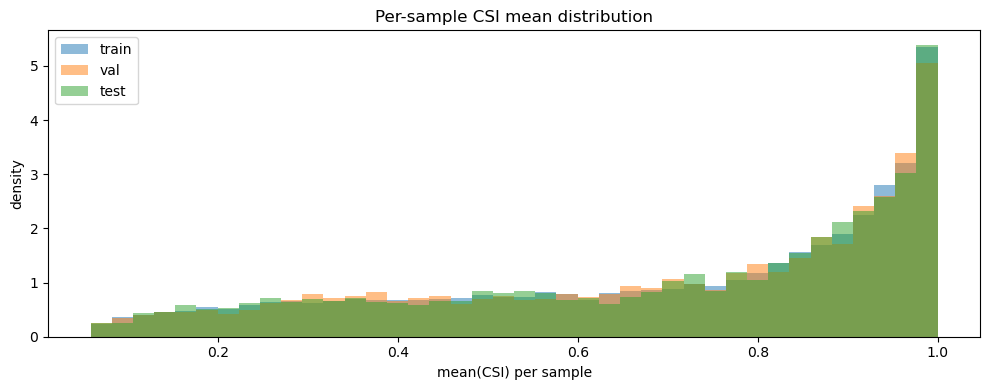

In [9]:
report = summarize_split_csi_mean(
    y,
    idx_train=idx_train,
    idx_val=idx_val,
    idx_test=idx_test,
    bins=40,
    plot=True
)

In [16]:
channel_min = np.nanmin(X_train, axis=(0, 2, 3))  
channel_max = np.nanmax(X_train, axis=(0, 2, 3))

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

# np.savez(
#     "Data/static/minmax_stratified_tempnorm_noP4.npz",
#     channel_min=channel_min,
#     channel_max=channel_max,
# )

In [10]:
# import numpy as np

# 1. Calculate actual stats for all channels
channel_min = np.nanmin(X_train, axis=(0, 2, 3))  
channel_max = np.nanmax(X_train, axis=(0, 2, 3))

# 2. CREATE THE MASK: Overwrite channels 0 through 8
# This ensures (x - 0) / (1 - 0) = x for these channels
channel_min[0:9] = 0.0
channel_max[0:9] = 1.0

# 3. Protect against zero range for the remaining channels (9-11)
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6
# Update channel_max to ensure the range is exactly what we want
channel_max = channel_min + channel_range

# # 4. Save the "Modified" stats
# np.savez(
#     "Data/static/minmax_stratified_cancel_no4.npz",
#     channel_min=channel_min,
#     channel_max=channel_max,
# )

In [11]:
train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=8, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


## 3. Model Architecture and Training

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.7).to(device)
print(gate_stats(model, val_loader, device, K=2))

{'hard_usage': array([0.47321662, 0.52678335], dtype=float32), 'mean_max_weight': 0.5740409135818482, 'mean_entropy': 0.6746864944696427}


In [11]:
best_ckpt = train_gum(
    model, train_loader, val_loader, device,
    total_epochs=50,
    lr=1e-4, max_lr=3e-4,
    weight_decay=1e-3,
    lam_bal=0.001,
    full_val_every=5,
    val_batches_quick=30,
    ckpt_name="best_gum_tempnorm_nominmax_no4.pt"
)

/home/tjdu/Solar-Forecasting-over-Hong-Kong-Region/src/train.py:192: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


Ep 001/50 | temp=2.00 | train_loss=0.11467 | quick_rmse=0.16653 | H=0.524 | usage=[0.752 0.248] | lr=5.58e-05 | 96.2s | FULL_rmse=0.16513 (best=0.16513)
Ep 002/50 | temp=2.00 | train_loss=0.09448 | quick_rmse=0.14922 | H=0.508 | usage=[0.743 0.257] | lr=1.23e-04 | 89.5s
Ep 003/50 | temp=2.00 | train_loss=0.09025 | quick_rmse=0.17357 | H=0.531 | usage=[0.697 0.303] | lr=2.07e-04 | 89.5s
Ep 004/50 | temp=2.00 | train_loss=0.08222 | quick_rmse=0.15014 | H=0.565 | usage=[0.632 0.368] | lr=2.74e-04 | 89.3s
Ep 005/50 | temp=2.00 | train_loss=0.07625 | quick_rmse=0.15336 | H=0.583 | usage=[0.585 0.415] | lr=3.00e-04 | 89.3s
Ep 006/50 | temp=1.00 | train_loss=0.07067 | quick_rmse=0.13718 | H=0.555 | usage=[0.559 0.441] | lr=3.00e-04 | 95.1s | FULL_rmse=0.14079 (best=0.14079)
Ep 007/50 | temp=1.00 | train_loss=0.06755 | quick_rmse=0.11664 | H=0.558 | usage=[0.538 0.462] | lr=2.99e-04 | 89.4s
Ep 008/50 | temp=1.00 | train_loss=0.06595 | quick_rmse=0.11358 | H=0.567 | usage=[0.528 0.472] | lr=2.9

## 4. Evaluation and Performance Metrics

In [13]:
# --- load best model for evaluation ---
PATH = "Model_checkpoint/best_gum_temp_norm.pt"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)

<All keys matched successfully>

In [14]:
df_results = evaluate_table_metrics(
    model, 
    test_loader, 
    device, 
    cs_ghi_full=c1, 
    time_mins_full=t, 
    idx_eval=idx_test
)
display(df_results)

RMSE   rRMSE (%)         MAE         MBE  \
Target Category / Period                                                   
CSI    Clear sky            0.095908   10.372978    0.054197    0.002257   
       Cloudy sky           0.496949  219.246879    0.433607    0.427007   
       Morning (5-8)        0.245211   34.363022    0.155423    0.094357   
       Day (8-16)           0.255175   36.602223    0.157984    0.116774   
       Evening (16-19)      0.257368   36.914350    0.162256    0.104048   
       Overall (All sky)    0.254714   36.464367    0.158453    0.112882   
GHI    Clear sky           61.154864   11.081275   31.773256    1.440140   
       Cloudy sky         302.660431  236.911693  243.498042  240.259076   
       Morning (5-8)       57.810010   35.076600   35.156415   22.039846   
       Day (8-16)         174.256323   36.019740  105.257075   75.828698   
       Evening (16-19)     69.823854   36.399407   41.766557   26.557416   
       Overall (All sky)  155.100022   37.761973   89.310115   63.504043   

                                R2  
Target Category / Period            
CSI    Clear sky          0.472716  
       Cloudy sky        -9.004818  
       Morning (5-8)      0.351416  
       Day (8-16)         0.344305  
       Evening (16-19)    0.313946  
       Overall (All sky)  0.340246  
GHI    Clear sky          0.940830  
       Cloudy sky        -6.606638  
       Morning (5-8)      0.616399  
       Day (8-16)         0.572991  
       Evening (16-19)    0.721017  
       Overall (All sky)  0.675280

In [ ]:
df_results = evaluate_table_metrics(
    model, 
    test_loader, 
    device, 
    cs_ghi_full=c1, 
    time_mins_full=t, 
    idx_eval=idx_test
)
display(df_results)

RMSE  rRMSE (%)        MAE       MBE        R2
Target Category / Period                                                     
CSI    Clear sky           0.058814   6.361044   0.029333  0.002754  0.801713
       Cloudy sky          0.101286  44.685726   0.071073  0.010675  0.584396
       Morning (5-8)       0.124283  17.416612   0.075138 -0.005657  0.833386
       Day (8-16)          0.081306  11.662442   0.049409  0.003139  0.933432
       Evening (16-19)     0.100509  14.415968   0.062275  0.002110  0.895370
       Overall (All sky)   0.088889  12.725156   0.053598  0.002244  0.919653
GHI    Clear sky          36.465481   6.607553  16.845308  1.800518  0.978962
       Cloudy sky         57.569679  45.063473  38.240127  8.038481  0.724787
       Morning (5-8)      28.885492  17.526460  16.823689  0.093185  0.904229
       Day (8-16)         57.375638  11.859860  33.636900  2.771510  0.953707
       Evening (16-19)    25.370011  13.225471  15.503158  1.773815  0.963169
       Overall (All sky)  51.628739  12.569973  29.348737  2.389950  0.964019

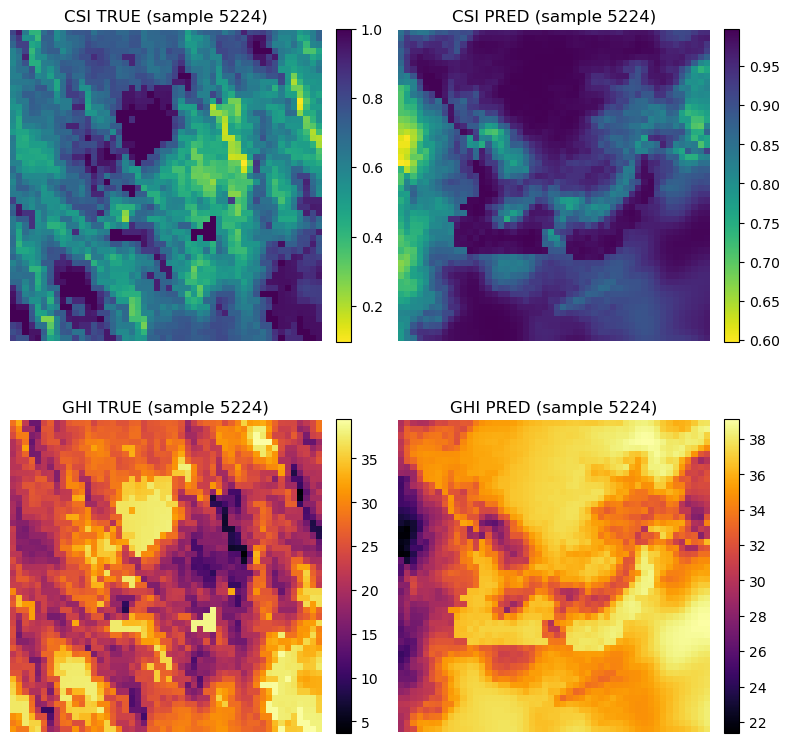

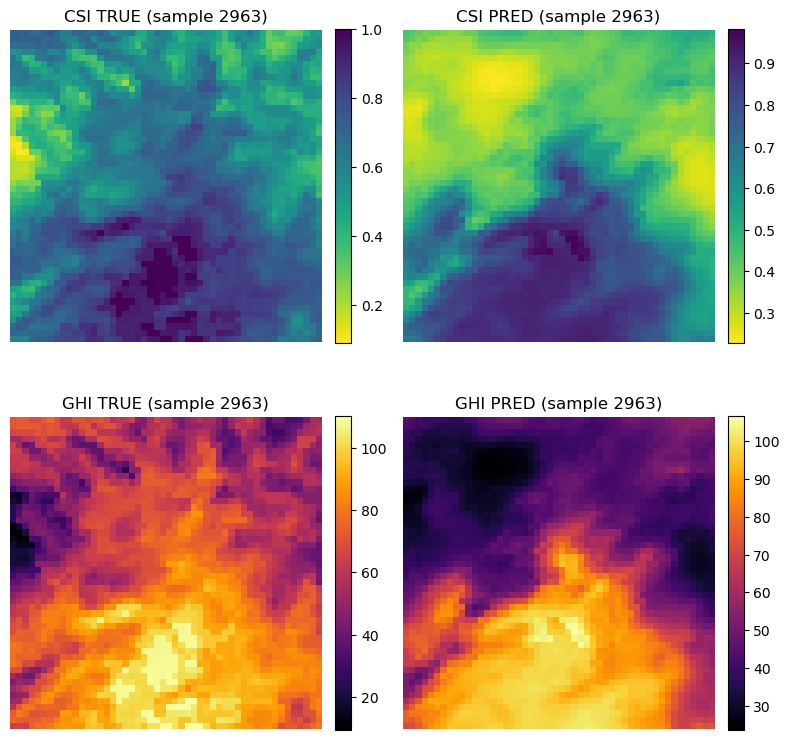

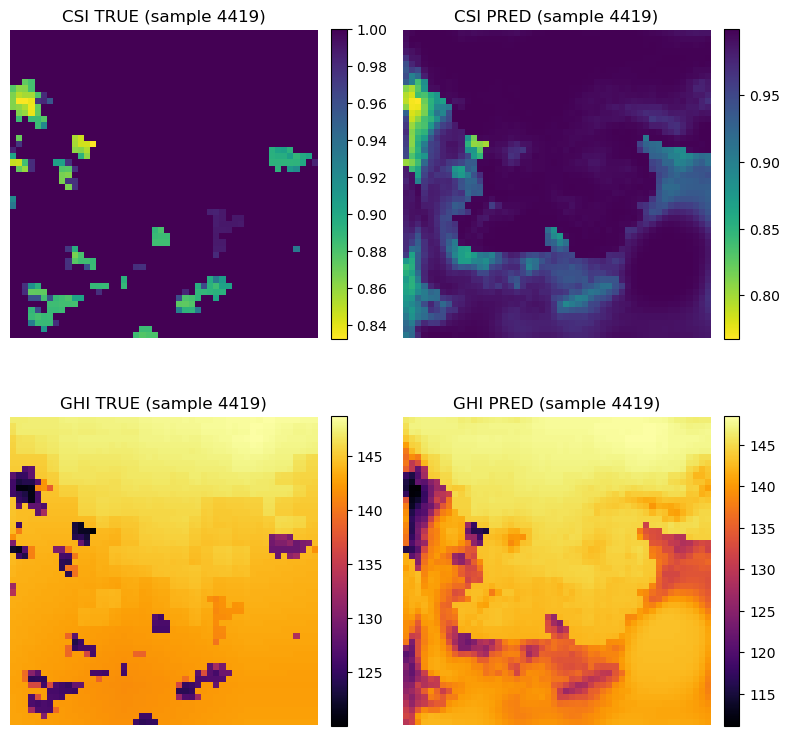

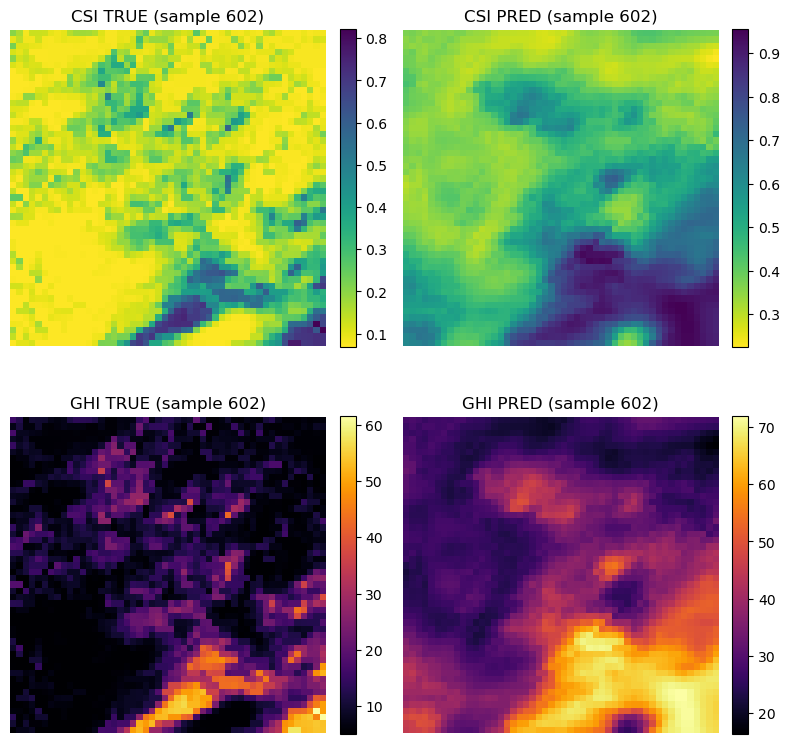

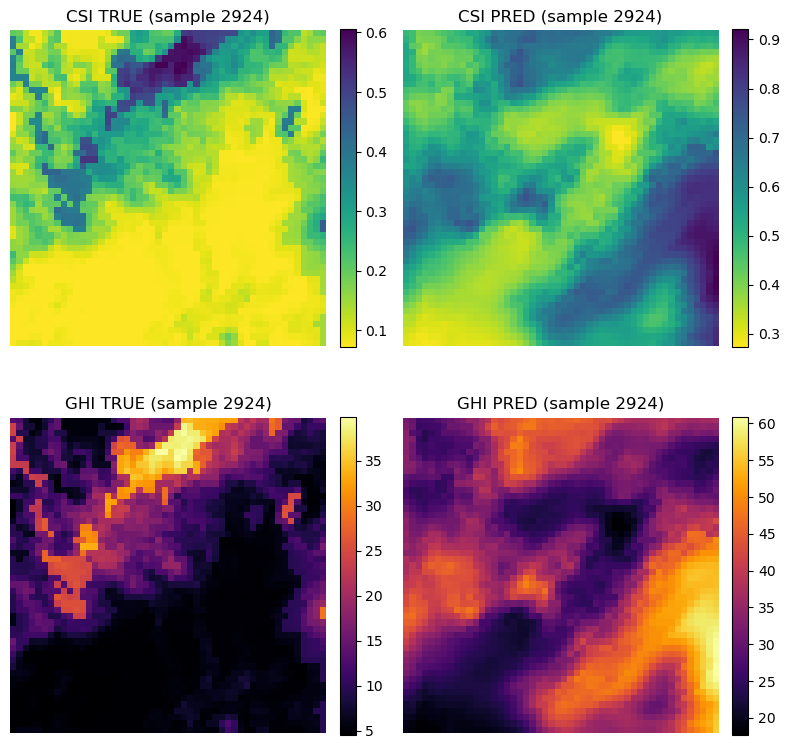

In [15]:
ghi_cs_all = cams_data[:, 1, :, :] 
ghi_cs_test = ghi_cs_all[idx_test]
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (T_test,H,W)
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=5,
    seed=42
)